lassification Model Evaluation in Machine Learning
Just like there is a bunch of machine learning algorithms that we can use to train classification models, the same way there is a bunch of metrics we can use to evaluate classification models. Below are some of the model evaluation metrics that you can use for classification model evaluation:

Confusion matrix
Accuracy
Classification report
AUC and ROC

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB

data = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/Youtube01-Psy.csv")
data = data[["CONTENT", "CLASS"]]
x = np.array(data["CONTENT"])
y = np.array(data["CLASS"])

cv = CountVectorizer()
x = cv.fit_transform(x)
xtrain, xtest, ytrain, ytest = train_test_split(x, y,
                                                test_size=0.2,
                                                random_state=42)

model = BernoulliNB()
model.fit(xtrain, ytrain)
predictions = model.predict(xtest)

In [2]:
# Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
confusionMatrix = confusion_matrix(ytest, predictions)
print(confusionMatrix)

[[27  0]
 [ 1 42]]


In [3]:
print(model.score(xtest, ytest))

0.9857142857142858


In [4]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(ytest, predictions))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      0.98      0.99        43

    accuracy                           0.99        70
   macro avg       0.98      0.99      0.99        70
weighted avg       0.99      0.99      0.99        70



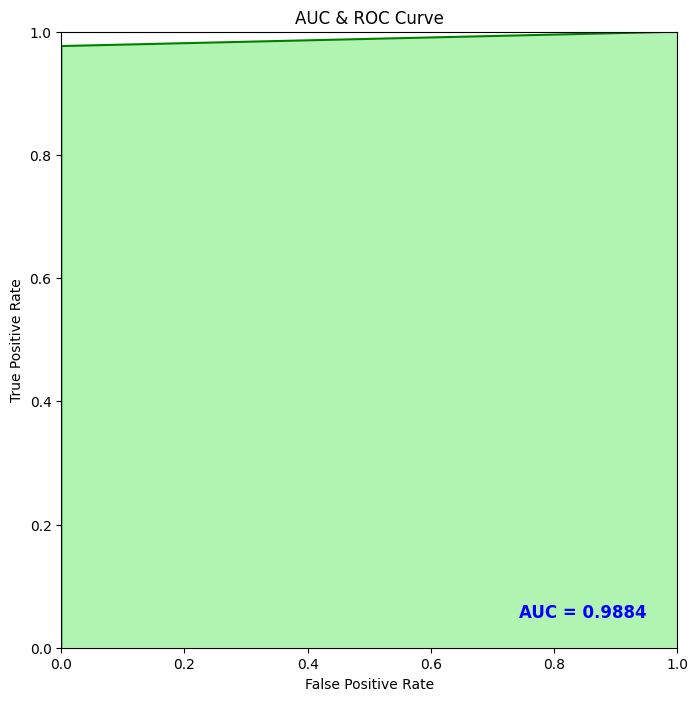

In [5]:
# AUC and ROC
import matplotlib.pyplot as plt
from sklearn import metrics
auc = metrics.roc_auc_score(ytest, predictions)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(ytest, predictions)

plt.figure(figsize=(10, 8), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate, 'g')
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightgreen', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [6]:
import joblib

# Save the trained model
joblib.dump(model, 'bernoulli_naive_bayes_model.joblib')

# Save the CountVectorizer
joblib.dump(cv, 'count_vectorizer.joblib')

print("Model and CountVectorizer saved successfully!")

Model and CountVectorizer saved successfully!


These files can now be uploaded to Hugging Face or loaded for future use.